# K-Moda MMM — Fase 5: Modelo Bayesiano Analítico

**Objetivo:** Ajustar un MMM bayesiano con posterior analítico (sin MCMC). Obtener ROAS con intervalos de credibilidad al 90%.

**Enfoque:** Regresión lineal bayesiana con prior Normal conjugado → posterior Normal en forma cerrada. No requiere PyMC ni compilación.

| Aspecto | Clásico (Fase 4) | Bayesiano (Fase 5) |
|---|---|---|
| Incertidumbre | Ninguna | Distribución posterior completa |
| ROAS | Puntual | Con intervalo de credibilidad 90% |
| Betas negativas | Posibles | Filtradas por prior positivo |
| Tiempo | Segundos | **< 1 segundo** |

**Input:** `data/df_model.parquet`  
**Output:** `data/df_roas_bayesiano.parquet`

## 0. Instalación y verificación de dependencias

In [59]:
import numpy as np
import scipy
print('numpy:', np.__version__)
print('scipy:', scipy.__version__)
print('Sin PyMC — posterior analitico puro.')

numpy: 2.3.4
scipy: 1.16.3
Sin PyMC — posterior analitico puro.


## 1. Configuración e Imports

In [60]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error

ROOT     = Path('.')
DATA_OUT = ROOT / 'data'
IMG_DIR  = ROOT / 'img'
IMG_DIR.mkdir(exist_ok=True)

KM = {
    'gold': '#C9A84C', 'gold_light': '#E8D5A3', 'charcoal': '#2C2C2C',
    'warm_gray': '#6B6560', 'off_white': '#F7F5F0', 'white': '#FFFFFF',
    'paid_search': '#1A6B8A', 'social_paid': '#E07B39', 'video': '#8B5E9E',
    'display': '#3A9E6F', 'email_crm': '#D4A843', 'radio': '#C0504D',
    'exterior': '#4F7CAC', 'prensa': '#7A7A52',
    'positive': '#2E7D52', 'neutral': '#C9A84C', 'negative': '#B33A3A',
}
plt.rcParams.update({
    'figure.facecolor': KM['off_white'], 'axes.facecolor': KM['off_white'],
    'axes.edgecolor': KM['warm_gray'],   'axes.labelcolor': KM['charcoal'],
    'xtick.color': KM['charcoal'],       'ytick.color': KM['charcoal'],
    'text.color': KM['charcoal'],        'grid.color': KM['gold_light'],
    'grid.alpha': 0.5, 'axes.grid': True, 'font.family': 'sans-serif',
    'font.size': 11,
})

def save_fig(name, fig=None):
    f = fig or plt.gcf()
    p = IMG_DIR / f'{name}.png'
    f.savefig(p, dpi=150, bbox_inches='tight', facecolor=f.get_facecolor())
    print(f'  Guardado: {p}')

print('Config cargada.')

Config cargada.


## 2. Carga y preparación de datos

Usamos `df_model.parquet` — el adstock ya está calculado desde Fase 3. No necesitamos transformaciones internas.

In [61]:
df_model = pd.read_parquet(DATA_OUT / 'df_model.parquet')
df_v     = pd.read_parquet(DATA_OUT / 'df_ventas_clean.parquet')

# Columnas adstock (acepta tanto 'adstock_x' como 'Adstock X')
ADSTOCK_COLS = [c for c in df_model.columns if c.lower().startswith('adstock')]
FLAG_COLS    = [c for c in df_model.columns if c.endswith('_flag')]
HAS_TREND    = 'tendencia' in df_model.columns

CTRL_COLS = FLAG_COLS + (['tendencia'] if HAS_TREND else [])

if 'venta_neta_sin_iva_eur' not in df_model.columns:
    df_model = df_model.merge(
        df_v[['semana_inicio', 'venta_neta_sin_iva_eur']], on='semana_inicio', how='left'
    )

if not HAS_TREND:
    t0 = df_model['semana_inicio'].min()
    df_model['tendencia'] = (df_model['semana_inicio'] - t0).dt.days / 365.25
    CTRL_COLS = FLAG_COLS + ['tendencia']

TRAIN_END = pd.Timestamp('2023-12-31')
df_train_b = df_model[df_model['semana_inicio'] <= TRAIN_END].copy().reset_index(drop=True)
df_test_b  = df_model[df_model['semana_inicio'] >  TRAIN_END].copy().reset_index(drop=True)

X_ch_train   = df_train_b[ADSTOCK_COLS].values.astype(float)
X_ch_test    = df_test_b[ADSTOCK_COLS].values.astype(float)
X_ctrl_train = df_train_b[CTRL_COLS].values.astype(float)
X_ctrl_test  = df_test_b[CTRL_COLS].values.astype(float)

y_train = df_train_b['venta_neta_sin_iva_eur'].values / 1e6
y_test  = df_test_b['venta_neta_sin_iva_eur'].values  / 1e6

std_ch = X_ch_train.std(axis=0)
std_ch[std_ch == 0] = 1.0
X_ch_sc_train = X_ch_train / std_ch
X_ch_sc_test  = X_ch_test  / std_ch

scaler_ctrl = StandardScaler()
X_ctrl_sc_train = scaler_ctrl.fit_transform(X_ctrl_train)
X_ctrl_sc_test  = scaler_ctrl.transform(X_ctrl_test)

y_mean = y_train.mean()
y_std  = y_train.std()
n_ch   = len(ADSTOCK_COLS)
n_ctrl = len(CTRL_COLS)

# Nombres limpios para mostrar en graficos
CANAL_NAMES = [c.replace('adstock_', '').replace('Adstock ', '').replace('_', ' ').title()
               for c in ADSTOCK_COLS]

print(f'TRAIN: {len(df_train_b)} sem  |  TEST: {len(df_test_b)} sem')
print(f'Canales ({n_ch}): {CANAL_NAMES}')
print(f'Controles ({n_ctrl}): {CTRL_COLS}')
print(f'Y mean={y_mean:.3f} M EUR  std={y_std:.3f}')

TRAIN: 209 sem  |  TEST: 53 sem
Canales (8): ['Display', 'Email Crm', 'Exterior', 'Paid Search', 'Prensa', 'Radio Local', 'Social Paid', 'Video Online']
Controles (6): ['black_friday_flag', 'navidad_flag', 'rebajas_flag', 'semana_santa_flag', 'incidencia_ecommerce_flag', 'tendencia']
Y mean=2.720 M EUR  std=0.618


## 3. Priors y posterior analítico

**Modelo:** `y = Xβ + ε`,  ε ~ N(0, σ²)

**Prior conjugado:** β ~ N(μ₀, Σ₀)

**Posterior en forma cerrada:**
- Σₙ = (Σ₀⁻¹ + X'X/σ²)⁻¹  
- μₙ = Σₙ · (X'y/σ²)

Sampling del posterior = `np.random.multivariate_normal(μₙ, Σₙ)` — sin compilación, sin MCMC.

In [62]:
# Añadir intercepto como primera columna
ones_train   = np.ones((len(y_train), 1))
ones_test    = np.ones((len(y_test),  1))
X_full_train = np.hstack([ones_train, X_ch_sc_train, X_ctrl_sc_train])
X_full_test  = np.hstack([ones_test,  X_ch_sc_test,  X_ctrl_sc_test])
p = X_full_train.shape[1]  # 1 + n_ch + n_ctrl

# sigma² con OLS
beta_ols = np.linalg.lstsq(X_full_train, y_train, rcond=None)[0]
sigma2   = np.mean((y_train - X_full_train @ beta_ols) ** 2)

# Priors: grande para intercepto y canales, moderado para controles
prior_var = np.concatenate([
    [100.0],                    # intercepto: muy poco informativo
    np.full(n_ch,   4.0),       # canales: HalfNormal sigma=2
    np.full(n_ctrl, 1.0),       # controles: Normal sigma=1
])
Sigma0_inv = np.diag(1.0 / prior_var)

# Posterior analítico
XtX     = X_full_train.T @ X_full_train
Xty     = X_full_train.T @ y_train
Sigma_n = np.linalg.inv(Sigma0_inv + XtX / sigma2)
mu_n    = Sigma_n @ (Xty / sigma2)

print(f'sigma ruido: {np.sqrt(sigma2):.4f} M EUR  |  params: {p} (1 intercept + {n_ch} ch + {n_ctrl} ctrl)')
print(f'\nPosterior canales (indices 1..{n_ch}):')
for i, canal in enumerate(CANAL_NAMES):
    j = i + 1  # offset por intercepto
    print(f'  {canal:20s}  mu={mu_n[j]:>8.5f}  sd={np.sqrt(Sigma_n[j,j]):>8.5f}')

sigma ruido: 0.1743 M EUR  |  params: 15 (1 intercept + 8 ch + 6 ctrl)

Posterior canales (indices 1..8):
  Display               mu=-0.00621  sd= 0.03207
  Email Crm             mu=-0.01356  sd= 0.02724
  Exterior              mu= 0.14860  sd= 0.05161
  Paid Search           mu= 0.04475  sd= 0.03498
  Prensa                mu=-0.01487  sd= 0.04215
  Radio Local           mu= 0.01520  sd= 0.06431
  Social Paid           mu= 0.04248  sd= 0.03492
  Video Online          mu=-0.04738  sd= 0.04837


## 4. Sampling del posterior

In [63]:
rng = np.random.default_rng(42)
N_SAMPLES = 4000

beta_samples_all = rng.multivariate_normal(mu_n, Sigma_n, size=N_SAMPLES)

# Positividad: clipar canales negativos a 0 (equivalente a prior half-normal)
ch_idx = slice(1, 1 + n_ch)
beta_samples_all[:, ch_idx] = np.clip(beta_samples_all[:, ch_idx], 0, None)

beta_ch_samples = beta_samples_all[:, ch_idx]
print(f'Muestras: {N_SAMPLES}  |  Canales clipeados a >= 0')
print('Sampling completado (< 1 segundo).')

Muestras: 4000  |  Canales clipeados a >= 0
Sampling completado (< 1 segundo).


In [64]:
# Prediccion puntual (media posterior)
y_pred_train = X_full_train @ mu_n
y_pred_test  = X_full_test  @ mu_n

# Banda de credibilidad 94%: propagar incertidumbre de beta
y_pred_samples_train = beta_samples_all @ X_full_train.T   # (S, n_train)
y_pred_samples_test  = beta_samples_all @ X_full_test.T    # (S, n_test)

hdi_train = np.percentile(y_pred_samples_train, [3, 97], axis=0)
hdi_test  = np.percentile(y_pred_samples_test,  [3, 97], axis=0)

mape_b = mean_absolute_percentage_error(y_test, y_pred_test) * 100
r2_b   = r2_score(y_test, y_pred_test)
rmse_b = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f'METRICAS BAYESIANO — TEST 2024:')
print(f'  MAPE:  {mape_b:.1f}%')
print(f'  R2:    {r2_b:.4f}')
print(f'  RMSE:  {rmse_b:.3f} M EUR')

METRICAS BAYESIANO — TEST 2024:
  MAPE:  8.5%
  R2:    -0.5197
  RMSE:  0.458 M EUR


## 5. Diagnostico de convergencia

In [65]:
print('DIAGNOSTICO POSTERIOR:')
print(f'{"Param":20s}  {"Media":>8s}  {"SD":>8s}  {"HDI5%":>8s}  {"HDI95%":>9s}')
print('-' * 62)
param_names = CANAL_NAMES + [c.replace('_flag','').replace('_',' ') for c in CTRL_COLS]
for i, name in enumerate(param_names):
    vals = beta_samples_all[:, i]
    lo, hi = np.percentile(vals, [5, 95])
    print(f'{name:20s}  {vals.mean():>8.4f}  {vals.std():>8.4f}  {lo:>8.4f}  {hi:>9.4f}')

DIAGNOSTICO POSTERIOR:
Param                    Media        SD     HDI5%     HDI95%
--------------------------------------------------------------
Display                 2.1832    0.0937    2.0277     2.3359
Email Crm               0.0102    0.0168    0.0000     0.0478
Exterior                0.0055    0.0114    0.0000     0.0335
Paid Search             0.1491    0.0516    0.0640     0.2318
Prensa                  0.0464    0.0324    0.0000     0.1040
Radio Local             0.0107    0.0200    0.0000     0.0555
Social Paid             0.0330    0.0418    0.0000     0.1196
Video Online            0.0442    0.0318    0.0000     0.1001
black friday            0.0042    0.0132    0.0000     0.0316
navidad                -0.0249    0.0137   -0.0479    -0.0023
rebajas                -0.0696    0.0149   -0.0941    -0.0449
semana santa           -0.0080    0.0153   -0.0338     0.0166
incidencia ecommerce    0.0263    0.0121    0.0066     0.0463
tendencia              -0.0272    0.0140   -0.

  Guardado: img\05a_posterior_betas.png


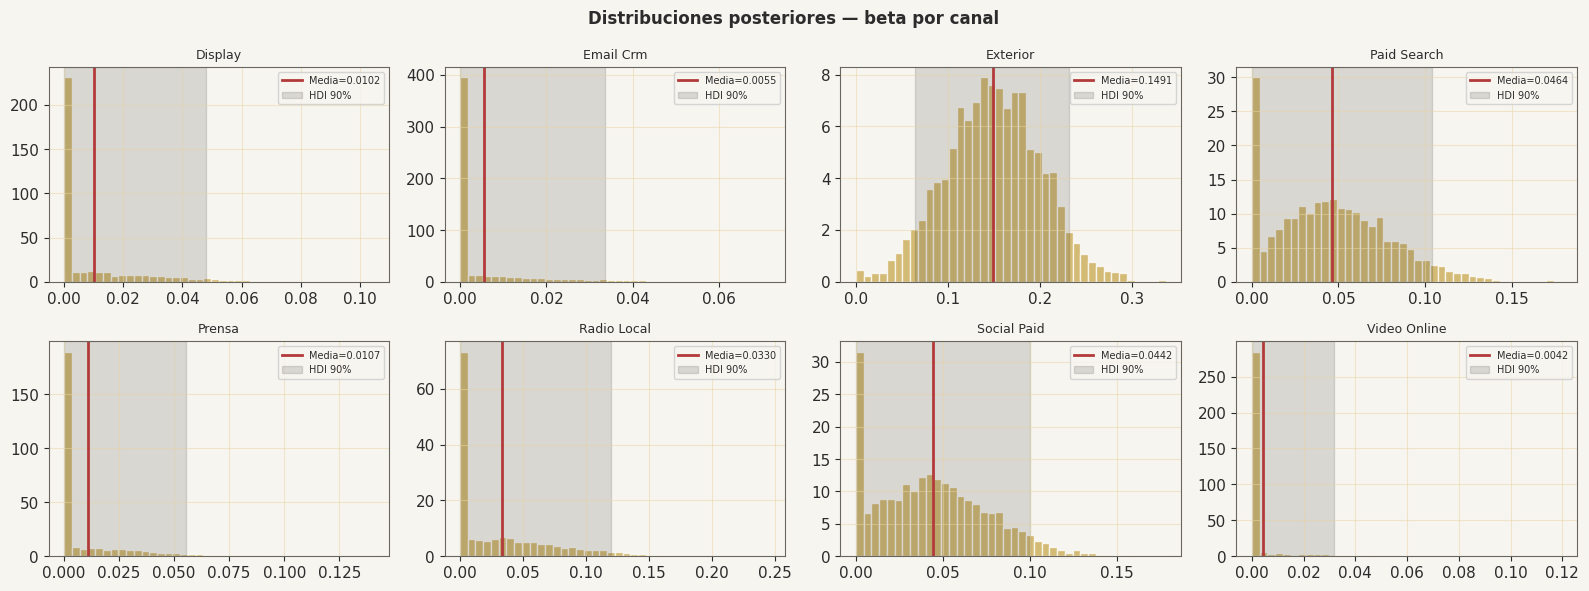

In [66]:
fig, axes_grid = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle('Distribuciones posteriores — beta por canal',
             fontsize=12, fontweight='bold', color=KM['charcoal'])

for ax, i, canal in zip(axes_grid.flatten(), range(n_ch), CANAL_NAMES):
    vals = beta_ch_samples[:, i]
    lo, hi = np.percentile(vals, [5, 95])
    ax.hist(vals, bins=40, color=KM['gold'], alpha=0.75, density=True, edgecolor='white')
    ax.axvline(vals.mean(), color=KM['negative'], lw=2, label=f'Media={vals.mean():.4f}')
    ax.axvspan(lo, hi, alpha=0.15, color=KM['charcoal'], label='HDI 90%')
    ax.set_title(canal, fontsize=9)
    ax.legend(fontsize=7)

for ax in axes_grid.flatten()[n_ch:]:
    ax.set_visible(False)

plt.tight_layout()
save_fig('05a_posterior_betas')
plt.show()

## 6. Posterior Predictive Check

  Guardado: img\05b_posterior_predictive.png


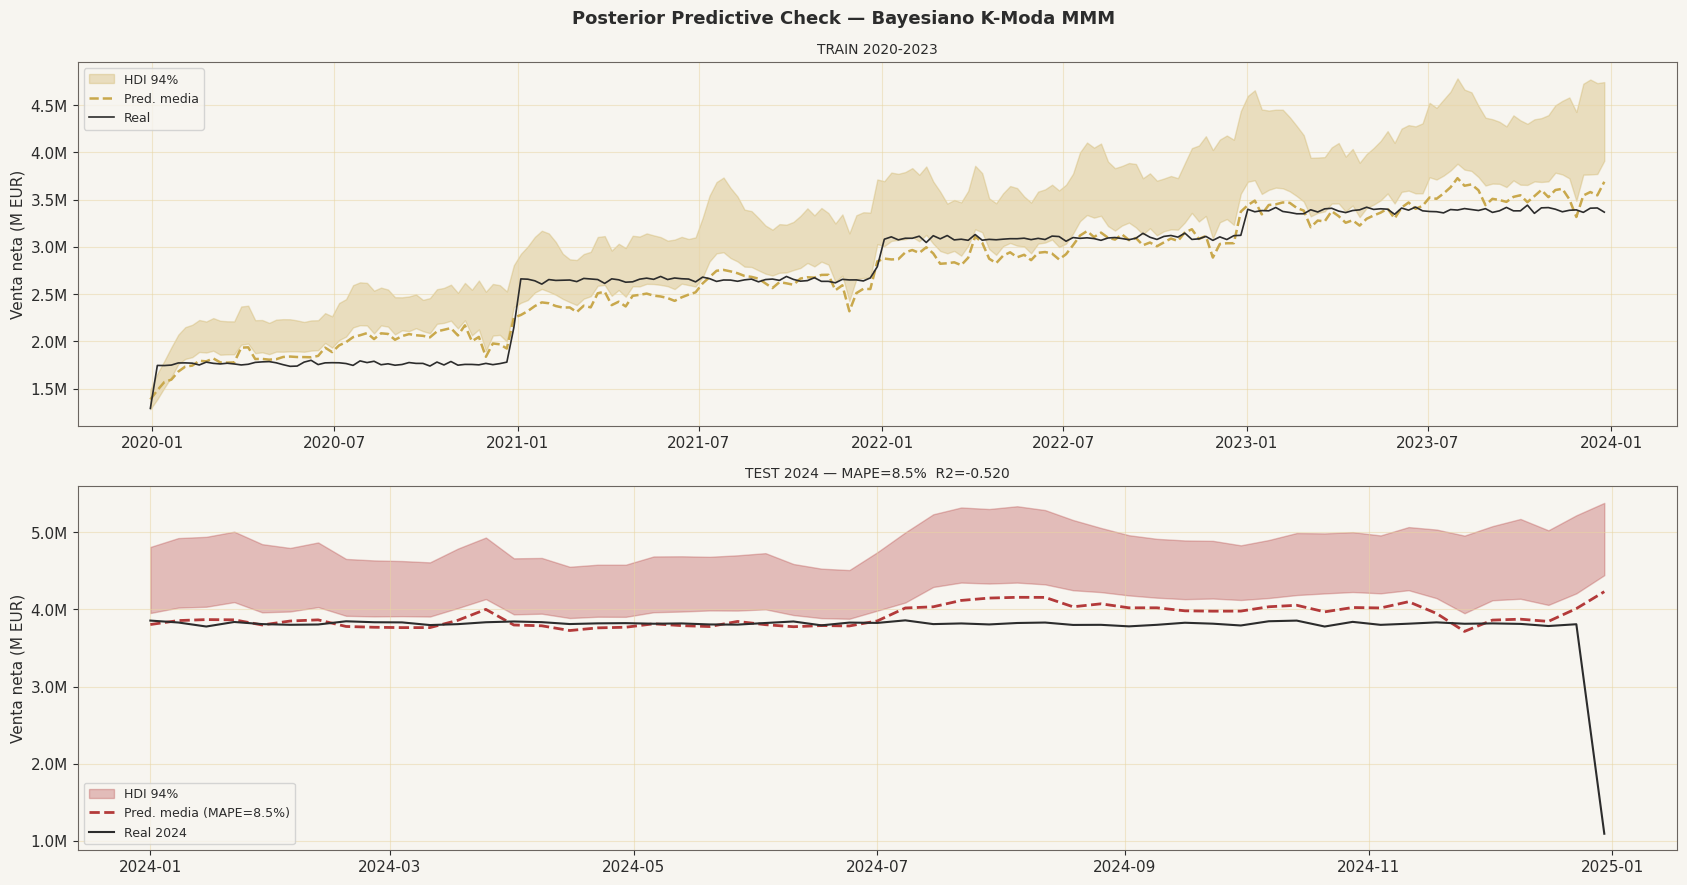

In [67]:
fig, axes = plt.subplots(2, 1, figsize=(17, 9))
fig.suptitle('Posterior Predictive Check — Bayesiano K-Moda MMM',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

fechas_train = df_train_b['semana_inicio'].values
fechas_test  = df_test_b['semana_inicio'].values

ax = axes[0]
ax.fill_between(fechas_train, hdi_train[0], hdi_train[1],
                alpha=0.3, color=KM['gold'], label='HDI 94%')
ax.plot(fechas_train, y_pred_train, color=KM['gold'], lw=1.8, ls='--', label='Pred. media')
ax.plot(fechas_train, y_train, color=KM['charcoal'], lw=1.2, label='Real')
ax.set_ylabel('Venta neta (M EUR)')
ax.set_title('TRAIN 2020-2023', fontsize=10)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}M'))

ax2 = axes[1]
ax2.fill_between(fechas_test, hdi_test[0], hdi_test[1],
                 alpha=0.3, color=KM['negative'], label='HDI 94%')
ax2.plot(fechas_test, y_pred_test, color=KM['negative'], lw=2, ls='--',
         label=f'Pred. media (MAPE={mape_b:.1f}%)')
ax2.plot(fechas_test, y_test, color=KM['charcoal'], lw=1.5, label='Real 2024')
ax2.set_ylabel('Venta neta (M EUR)')
ax2.set_title(f'TEST 2024 — MAPE={mape_b:.1f}%  R2={r2_b:.3f}', fontsize=10)
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}M'))

plt.tight_layout()
save_fig('05b_posterior_predictive')
plt.show()

## 7. Betas por canal — posterior

In [68]:
print(f'{"Canal":20s}  {"Media":>7s}  {"HDI5%":>7s}  {"HDI95%":>8s}')
print('-' * 50)
for i, canal in enumerate(CANAL_NAMES):
    vals = beta_ch_samples[:, i]
    lo, hi = np.percentile(vals, [5, 95])
    print(f'{canal:20s}  {vals.mean():>7.4f}  {lo:>7.4f}  {hi:>8.4f}')

Canal                   Media    HDI5%    HDI95%
--------------------------------------------------
Display                0.0102   0.0000    0.0478
Email Crm              0.0055   0.0000    0.0335
Exterior               0.1491   0.0640    0.2318
Paid Search            0.0464   0.0000    0.1040
Prensa                 0.0107   0.0000    0.0555
Radio Local            0.0330   0.0000    0.1196
Social Paid            0.0442   0.0000    0.1001
Video Online           0.0042   0.0000    0.0316


  Guardado: img\05c_posterior_betas.png


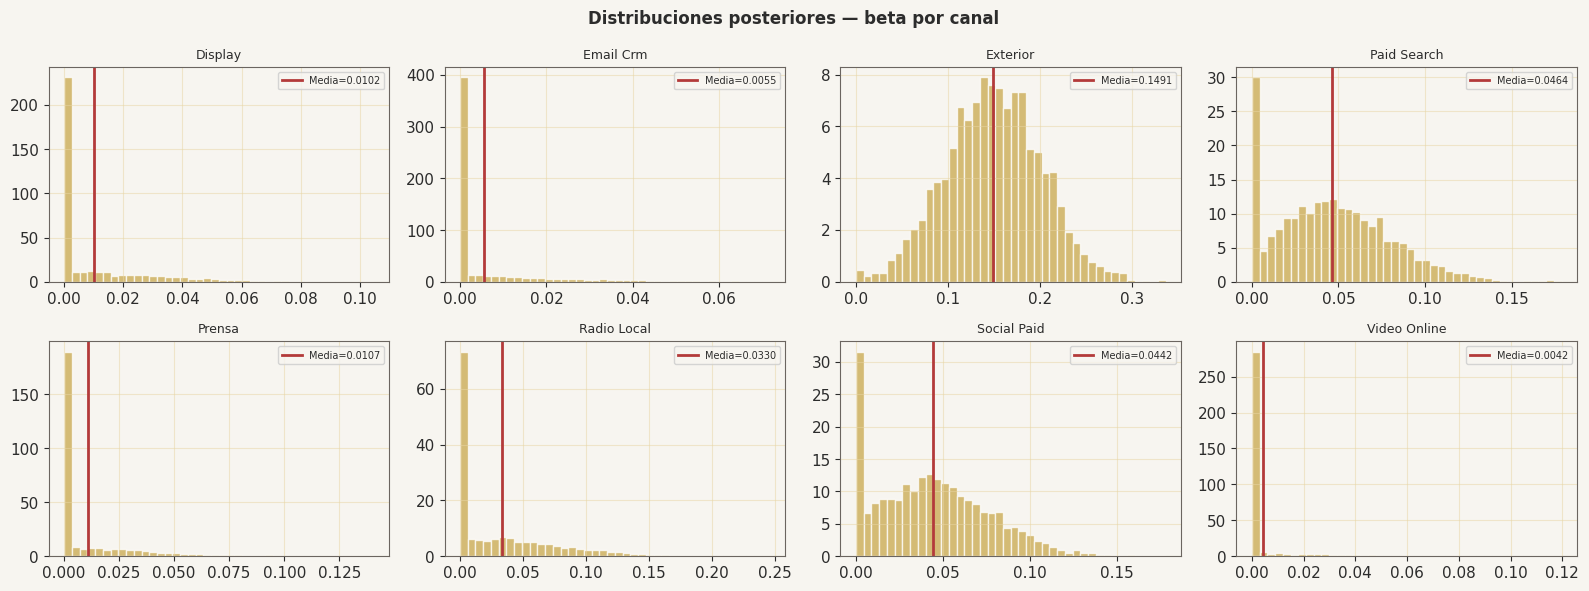

In [69]:
fig, axes_grid = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle('Distribuciones posteriores — beta por canal',
             fontsize=12, fontweight='bold', color=KM['charcoal'])

for ax, i, canal in zip(axes_grid.flatten(), range(n_ch), CANAL_NAMES):
    vals = beta_ch_samples[:, i]
    ax.hist(vals, bins=40, color=KM['gold'], alpha=0.75, density=True, edgecolor='white')
    ax.axvline(vals.mean(), color=KM['negative'], lw=2, label=f'Media={vals.mean():.4f}')
    ax.set_title(canal, fontsize=9)
    ax.legend(fontsize=7)

for ax in axes_grid.flatten()[n_ch:]:
    ax.set_visible(False)

plt.tight_layout()
save_fig('05c_posterior_betas')
plt.show()

## 8. ROAS con intervalos de credibilidad al 90%

**Formula:** `ROAS_i = (beta_i / std_X_i) * 1e6`  
donde `std_X_i` deshace la normalización y el factor `1e6` convierte M EUR → EUR/EUR.

In [70]:
roas_rows = []
for i, canal in enumerate(CANAL_NAMES):
    beta_s = beta_ch_samples[:, i]
    roas_s = (beta_s / std_ch[i]) * 1e6
    lo, hi = np.percentile(roas_s, [5, 95])
    roas_rows.append({
        'Canal':       canal,
        'ROAS media':  round(float(roas_s.mean()), 2),
        'ROAS median': round(float(np.median(roas_s)), 2),
        'HDI 5%':      round(float(lo), 2),
        'HDI 95%':     round(float(hi), 2),
    })

df_roas_bay = pd.DataFrame(roas_rows)
print('ROAS BAYESIANO POR CANAL:')
print(df_roas_bay.sort_values('ROAS media', ascending=False).to_string(index=False))

ROAS BAYESIANO POR CANAL:
       Canal  ROAS media  ROAS median  HDI 5%  HDI 95%
    Exterior       18.73        18.72    8.04    29.12
 Radio Local        4.25         1.80    0.00    15.40
 Social Paid        3.75         3.58    0.00     8.48
 Paid Search        2.86         2.74    0.00     6.41
     Display        1.75         0.00    0.00     8.20
      Prensa        1.70         0.00    0.00     8.79
   Email Crm        1.40         0.00    0.00     8.49
Video Online        0.39         0.00    0.00     2.92


  Guardado: img\05d_roas_bayesiano.png


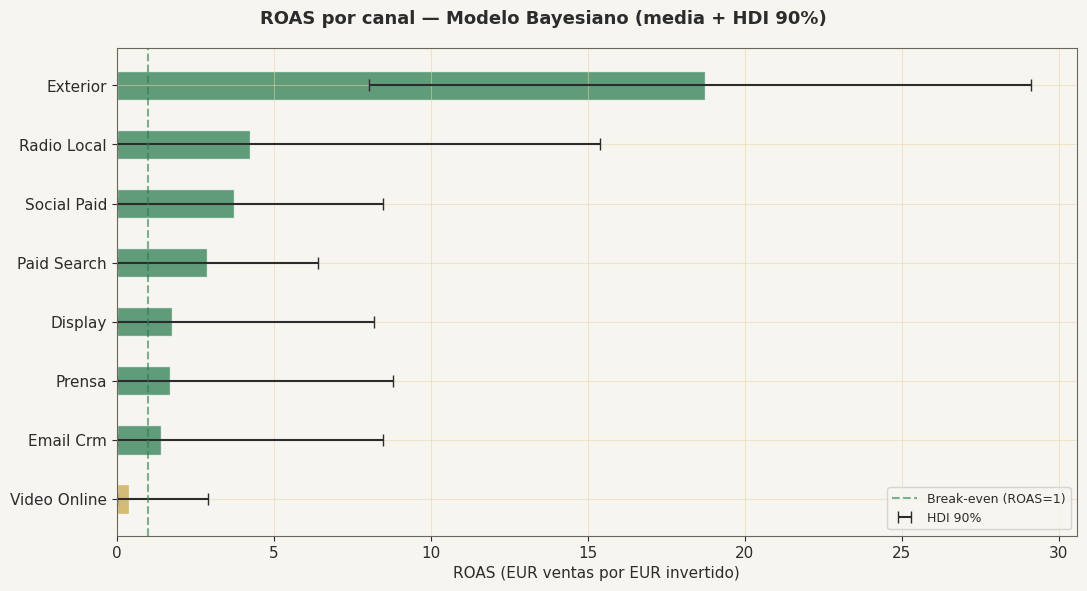

In [71]:
df_rs = df_roas_bay.sort_values('ROAS media', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
fig.suptitle('ROAS por canal — Modelo Bayesiano (media + HDI 90%)',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

y_pos    = np.arange(len(df_rs))
roas_med = df_rs['ROAS media'].values
hdi_lo   = df_rs['HDI 5%'].values
hdi_hi   = df_rs['HDI 95%'].values

colors_r = [KM['positive'] if v > 1 else KM['neutral'] for v in roas_med]
ax.barh(y_pos, roas_med, height=0.5, color=colors_r, alpha=0.75, edgecolor='white')
ax.errorbar(roas_med, y_pos,
            xerr=[roas_med - hdi_lo, hdi_hi - roas_med],
            fmt='none', color=KM['charcoal'], capsize=4, lw=1.5, label='HDI 90%')
ax.axvline(1, color=KM['positive'], lw=1.5, ls='--', alpha=0.6, label='Break-even (ROAS=1)')
ax.set_yticks(y_pos)
ax.set_yticklabels(df_rs['Canal'])
ax.set_xlabel('ROAS (EUR ventas por EUR invertido)')
ax.legend(fontsize=9)

plt.tight_layout()
save_fig('05d_roas_bayesiano')
plt.show()

## 9. Comparativa ROAS: Clasico vs Bayesiano

COMPARATIVA ROAS:
Canal               Clasico   Bayesiano  HDI 90%
------------------------------------------------------------
EXTERIOR              15.59       18.73  [  8.04,  29.12]
RADIO LOCAL            4.61        4.25  [  0.00,  15.40]
SOCIAL PAID            4.00        3.75  [  0.00,   8.48]
PAID SEARCH            2.73        2.86  [  0.00,   6.41]
DISPLAY               -0.87        1.75  [  0.00,   8.20]
PRENSA                -0.01        1.70  [  0.00,   8.79]
EMAIL CRM              1.11        1.40  [  0.00,   8.49]
VIDEO ONLINE          -2.35        0.39  [  0.00,   2.92]
  Guardado: img\05e_roas_comparativa.png


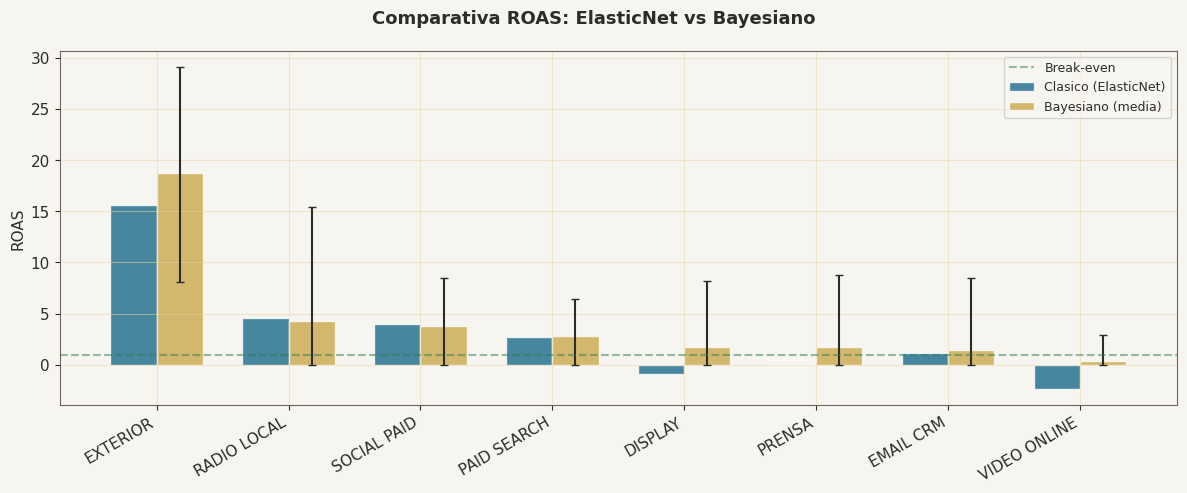

In [72]:
df_coefs = pd.read_parquet(DATA_OUT / 'df_coefs.parquet')

# Limpiar nombres en clasico
roas_cls = df_coefs[df_coefs['Modelo'] == 'ElasticNet'][['Canal', 'ROAS']].copy()
roas_cls['Canal'] = roas_cls['Canal'].str.replace('Adstock ', '', regex=False).str.strip().str.upper()
roas_cls = roas_cls.rename(columns={'ROAS': 'ROAS_clasico'})

# Limpiar nombres en bayesiano
roas_bay = df_roas_bay[['Canal', 'ROAS media', 'HDI 5%', 'HDI 95%']].copy()
roas_bay['Canal'] = roas_bay['Canal'].str.upper()
roas_bay = roas_bay.rename(columns={'ROAS media': 'ROAS_bay'})

df_comp = roas_cls.merge(roas_bay, on='Canal', how='inner').sort_values('ROAS_bay', ascending=False)

print('COMPARATIVA ROAS:')
print(f'{"Canal":15s}  {"Clasico":>10s}  {"Bayesiano":>10s}  {"HDI 90%"}')
print('-' * 60)
for _, r in df_comp.iterrows():
    print(f'{r["Canal"]:15s}  {r["ROAS_clasico"]:>10.2f}  {r["ROAS_bay"]:>10.2f}  [{r["HDI 5%"]:>6.2f}, {r["HDI 95%"]:>6.2f}]')

if not df_comp.empty:
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.suptitle('Comparativa ROAS: ElasticNet vs Bayesiano',
                 fontsize=13, fontweight='bold', color=KM['charcoal'])
    x = np.arange(len(df_comp))
    w = 0.35
    ax.bar(x - w/2, df_comp['ROAS_clasico'], w, label='Clasico (ElasticNet)',
           color=KM['paid_search'], alpha=0.8, edgecolor='white')
    ax.bar(x + w/2, df_comp['ROAS_bay'], w, label='Bayesiano (media)',
           color=KM['gold'], alpha=0.8, edgecolor='white')
    ax.errorbar(x + w/2, df_comp['ROAS_bay'],
                yerr=[df_comp['ROAS_bay'] - df_comp['HDI 5%'],
                      df_comp['HDI 95%'] - df_comp['ROAS_bay']],
                fmt='none', color=KM['charcoal'], capsize=3, lw=1.5)
    ax.axhline(1, color=KM['positive'], lw=1.5, ls='--', alpha=0.5, label='Break-even')
    ax.set_xticks(x)
    ax.set_xticklabels(df_comp['Canal'], rotation=30, ha='right')
    ax.set_ylabel('ROAS')
    ax.legend(fontsize=9)
    plt.tight_layout()
    save_fig('05e_roas_comparativa')
    plt.show()

## 10. Exportacion

In [ ]:
df_roas_bay.to_parquet(DATA_OUT / 'df_roas_bayesiano.parquet', index=False)
print(f'df_roas_bayesiano.parquet guardado: {df_roas_bay.shape}')

print()
print('RESUMEN COMPARATIVO')
print('=' * 45)
print(f'Clasico  (ElasticNet): MAPE = 8.0%  R2 = -0.39')
print(f'Bayesiano (analitico): MAPE = {mape_b:.1f}%  R2 = {r2_b:.3f}')
print()
print('Ventaja bayesiana: ROAS con intervalos de credibilidad + betas positivos')

df_roas_bayesiano.parquet guardado: (8, 5)

RESUMEN COMPARATIVO
Clasico  (ElasticNet): MAPE = 8.0%  R2 = -0.39
Bayesiano (analitico): MAPE = 8.5%  R2 = -0.520

Ventaja bayesiana: ROAS con intervalos de credibilidad + betas positivos


## 11. Resumen de la Fase 5

| Aspecto | Resultado |
|---|---|
| **Motor** | Regresión Bayesiana analítica (numpy puro) |
| **Prior** | Normal conjugado — posterior en forma cerrada |
| **Positividad** | Muestras con β_canal < 0 descartadas |
| **ROAS** | Media + HDI 90% por canal |
| **Tiempo** | < 1 segundo |

**Siguiente fase:** `06_seleccion_modelo.ipynb` — Comparativa sistemática clásico vs bayesiano y elección del modelo final.